# 딥러닝 주요 구조 개념 정리

이번 실습에서는 딥러닝 모델에서 자주 사용되는 Inception, ResNet, SENet, Depthwise Separable Convolution, Transformer의 핵심 개념을 정리해보겠습니다.

각 구조의 모양만 외우기보다 다음 내용을 중심으로 확인합니다.

1. 어떤 문제를 해결하기 위해 등장했는가
2. 정보가 어떤 방식으로 처리되는가
3. 파라미터와 연산량에는 어떤 변화가 있는가
4. 장점과 한계는 무엇인가
5. 어떤 문제에 적용할 수 있는가

주의할 점은 다섯 항목이 완전히 같은 종류의 모델은 아니라는 것입니다.

- Inception, ResNet, Transformer는 전체 모델을 구성하는 대표적인 설계 방식입니다.
- SENet은 기존 CNN에 추가하여 채널 중요도를 학습하는 모듈입니다.
- Depthwise convolution은 합성곱의 계산량을 줄이기 위한 연산 방식이며, 보통 pointwise convolution과 함께 사용합니다.

## 1. 필요한 라이브러리 불러오기

무거운 딥러닝 프레임워크 없이도 핵심 계산을 확인할 수 있도록 `numpy`, `pandas`, `matplotlib`, `seaborn`을 사용하겠습니다.

실제 모델 구현에 사용할 수 있는 Keras 예시는 각 개념의 설명에 함께 제시합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", None)

## 2. Inception

### 2.1 Inception이 등장한 이유

이미지에서 중요한 특징의 크기는 모두 같지 않습니다. 작은 무늬는 작은 커널로 확인할 수 있지만, 넓은 영역의 형태를 확인하려면 더 큰 수용 영역이 필요합니다.

Inception은 하나의 커널 크기만 선택하지 않고 여러 연산을 병렬로 적용한 뒤 결과를 채널 방향으로 합칩니다.

```text
입력
 ├─ 1×1 Conv
 ├─ 1×1 Conv → 3×3 Conv
 ├─ 1×1 Conv → 5×5 Conv
 └─ 3×3 MaxPool → 1×1 Conv
              ↓
       채널 방향 Concatenate
```

각 경로의 높이와 너비는 같게 유지해야 하며, 출력 채널 수는 각 경로의 채널 수를 더한 값입니다.

입력이 `(28, 28, 192)`이고 각 경로가 64, 128, 32, 32채널을 출력한다면 최종 출력은 `(28, 28, 256)`이 됩니다.

### 2.2 1×1 합성곱의 역할

1×1 합성곱은 채널 정보를 섞고 비선형 변환을 추가할 수 있습니다. 또한 3×3 또는 5×5 합성곱 앞에서 입력 채널을 줄이는 병목 계층으로 사용하면 계산량을 줄일 수 있습니다.

합성곱의 파라미터 수는 bias를 제외하면 다음과 같습니다.

$$K_hK_wC_{in}C_{out}$$

아래에서는 3×3 합성곱을 바로 적용할 때와 1×1 합성곱으로 채널을 줄인 뒤 적용할 때를 비교하겠습니다.

In [2]:
def conv_parameters(kernel_size, in_channels, out_channels):
    return kernel_size * kernel_size * in_channels * out_channels

in_channels = 192
reduced_channels = 96
out_channels = 128

direct = conv_parameters(3, in_channels, out_channels)
bottleneck = (
    conv_parameters(1, in_channels, reduced_channels)
    + conv_parameters(3, reduced_channels, out_channels)
)

inception_result = pd.DataFrame({
    "구조": ["3×3 직접 적용", "1×1 채널 축소 후 3×3"],
    "파라미터 수": [direct, bottleneck],
    "직접 적용 대비 비율": [1.0, bottleneck / direct],
})
display(inception_result)
print(f"파라미터 감소율: {(1 - bottleneck / direct) * 100:.1f}%")
print("Inception 출력 채널:", 64 + 128 + 32 + 32)

,구조,파라미터 수,직접 적용 대비 비율
0,3×3 직접 적용,221184,1.000000
1,1×1 채널 축소 후 3×3,129024,0.583333


파라미터 감소율: 41.7%
Inception 출력 채널: 256


### 2.3 Inception의 장점과 한계

장점:

- 한 계층에서 여러 크기의 특징을 추출할 수 있습니다.
- 1×1 병목 구조로 큰 커널의 계산량을 줄일 수 있습니다.
- 세부 특징과 넓은 영역의 특징을 함께 고려할 수 있습니다.

한계:

- 병렬 경로가 많아 구조가 복잡합니다.
- 각 경로의 필터 수를 직접 설계해야 합니다.
- 이론적인 연산량 감소가 모든 하드웨어에서 같은 속도 향상으로 이어지는 것은 아닙니다.

Inception v2와 v3에서는 큰 합성곱을 작은 합성곱 여러 개로 나누거나, n×n 합성곱을 1×n과 n×1 합성곱으로 분해하여 효율을 높였습니다.

간단한 Keras 형태는 다음과 같습니다.

```python
branch1 = layers.Conv2D(64, 1, padding="same", activation="relu")(x)

branch2 = layers.Conv2D(96, 1, padding="same", activation="relu")(x)
branch2 = layers.Conv2D(128, 3, padding="same", activation="relu")(branch2)

branch3 = layers.Conv2D(16, 1, padding="same", activation="relu")(x)
branch3 = layers.Conv2D(32, 5, padding="same", activation="relu")(branch3)

branch4 = layers.MaxPooling2D(3, strides=1, padding="same")(x)
branch4 = layers.Conv2D(32, 1, padding="same", activation="relu")(branch4)

output = layers.Concatenate(axis=-1)([branch1, branch2, branch3, branch4])
```

## 3. ResNet

### 3.1 ResNet이 등장한 이유

CNN을 깊게 만들면 복잡한 특징을 학습할 수 있지만, 계층을 계속 추가한다고 학습 성능이 항상 좋아지는 것은 아닙니다.

매우 깊은 모델에서는 기울기 소실·폭주 문제와 함께, 더 깊은 모델의 학습 오차가 오히려 높아지는 degradation 문제가 나타날 수 있습니다. Degradation은 단순히 과적합과 같은 의미가 아니라 깊은 모델의 최적화가 어려워지는 현상입니다.

ResNet은 입력을 몇 개의 계층을 건너 출력에 더하는 shortcut connection을 사용합니다.

일반 블록이 원하는 함수 $H(x)$를 직접 학습한다면, ResNet은 다음 잔차를 학습합니다.

$$F(x)=H(x)-x$$

최종 출력은 다음과 같습니다.

$$y=F(x)+x$$

항등함수가 필요할 때 복잡한 변환을 새로 학습하기보다 $F(x)\approx0$으로 만들면 됩니다.

### 3.2 기울기 전달과 shape

잔차 블록의 미분은 다음과 같이 shortcut의 항등 성분을 포함합니다.

$$\frac{\partial y}{\partial x}=\frac{\partial F(x)}{\partial x}+I$$

이 식이 기울기가 절대 사라지지 않는다는 보장은 아니지만, 깊은 모델의 최적화를 쉽게 만듭니다.

`Add` 연산을 하려면 두 경로의 shape이 같아야 합니다. 공간 크기나 채널 수가 다르면 shortcut에 1×1 합성곱을 적용하여 shape을 맞춥니다.

In [3]:
# 실제 합성곱 대신 작은 벡터를 이용하여 잔차 연결의 동작을 확인합니다.
x = np.array([1.0, -2.0, 0.5, 3.0])
residual = np.array([0.2, 0.1, -0.4, 0.3])
y = x + residual

residual_demo = pd.DataFrame({
    "입력 x": x,
    "학습된 잔차 F(x)": residual,
    "출력 F(x)+x": y,
})
display(residual_demo)

print("잔차가 0이면 출력은 입력과 같습니다:", np.allclose(x + np.zeros_like(x), x))

,입력 x,학습된 잔차 F(x),출력 F(x)+x
0,1.0,0.2,1.2
1,-2.0,0.1,-1.9
2,0.5,-0.4,0.1
3,3.0,0.3,3.3


잔차가 0이면 출력은 입력과 같습니다: True


### 3.3 Basic Block과 Bottleneck Block

- Basic Block: `3×3 Conv → 3×3 Conv`, 주로 ResNet-18과 ResNet-34에서 사용합니다.
- Bottleneck Block: `1×1 Conv → 3×3 Conv → 1×1 Conv`, 주로 ResNet-50 이상에서 사용합니다.

```python
def residual_block(x, filters, stride=1):
    shortcut = x

    y = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=False)(y)
    y = layers.BatchNormalization()(y)

    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    return layers.ReLU()(layers.Add()([y, shortcut]))
```

장점:

- 깊은 신경망의 최적화를 쉽게 합니다.
- shortcut을 통해 정보와 기울기가 전달될 경로를 제공합니다.
- 분류, 탐지, 분할 모델의 범용 backbone으로 사용할 수 있습니다.

한계:

- 깊어질수록 계산량과 메모리는 여전히 증가합니다.
- shape이 다르면 projection shortcut이 필요합니다.
- 작은 데이터셋에서 큰 모델을 처음부터 학습하면 과적합할 수 있습니다.

## 4. SENet

### 4.1 SENet의 핵심 개념

SENet은 독립된 하나의 backbone이라기보다 기존 CNN에 추가할 수 있는 채널 주의 모듈입니다. CNN이 만든 특징맵에서 중요한 채널은 강조하고 덜 중요한 채널은 억제합니다.

입력 특징맵을 $U\in\mathbb{R}^{H\times W\times C}$라고 하겠습니다.

1. **Squeeze**: 각 채널의 공간 정보를 전역 평균 풀링으로 요약합니다.

$$z_c=\frac{1}{HW}\sum_{i=1}^{H}\sum_{j=1}^{W}U_c(i,j)$$

2. **Excitation**: 두 개의 완전연결층으로 채널 중요도를 계산합니다.

$$s=\sigma(W_2\delta(W_1z))$$

3. **Scale**: 중요도를 원래 특징맵의 각 채널에 곱합니다.

$$\widetilde{U}_c=s_cU_c$$

축소 비율이 $r$이면 bias를 제외한 추가 파라미터 수는 약 $2C^2/r$입니다.

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def se_forward(feature_map, reduction_ratio=2):
    # Squeeze: 공간축 평균
    z = feature_map.mean(axis=(0, 1))
    channels = z.shape[0]
    hidden = max(channels // reduction_ratio, 1)

    # 학습 가능한 Dense 가중치를 무작위 값으로 예시합니다.
    w1 = np.random.normal(0, 0.3, size=(channels, hidden))
    w2 = np.random.normal(0, 0.3, size=(hidden, channels))
    excitation = sigmoid(np.maximum(z @ w1, 0) @ w2)
    scaled = feature_map * excitation.reshape(1, 1, -1)
    return z, excitation, scaled


feature_map = np.random.rand(4, 4, 6)
squeezed, channel_weights, scaled_map = se_forward(feature_map)

print("입력 특징맵 shape:", feature_map.shape)
print("Squeeze 벡터 shape:", squeezed.shape)
print("채널 중요도:", np.round(channel_weights, 3))
print("출력 특징맵 shape:", scaled_map.shape)

입력 특징맵 shape: (4, 4, 6)
Squeeze 벡터 shape: (6,)
채널 중요도: [0.5   0.499 0.492 0.498 0.498 0.495]
출력 특징맵 shape: (4, 4, 6)


### 4.2 SENet의 장점과 한계

장점:

- 기존 CNN에 쉽게 추가할 수 있습니다.
- 적은 추가 비용으로 채널별 중요도를 학습합니다.
- ResNet이나 MobileNet 등 다양한 구조와 결합할 수 있습니다.

한계:

- 채널 관계에 집중하므로 중요한 공간 위치는 직접 표현하지 않습니다.
- 채널 수가 매우 크면 완전연결층의 파라미터도 증가합니다.
- 항상 큰 성능 향상을 보장하는 것은 아닙니다.

```python
def se_block(inputs, reduction_ratio=16):
    channels = inputs.shape[-1]
    x = layers.GlobalAveragePooling2D()(inputs)
    x = layers.Dense(max(channels // reduction_ratio, 1), activation="relu")(x)
    x = layers.Dense(channels, activation="sigmoid")(x)
    x = layers.Reshape((1, 1, channels))(x)
    return layers.Multiply()([inputs, x])
```

## 5. Depthwise Separable Convolution

### 5.1 공간 특징 추출과 채널 결합 분리

일반 합성곱은 공간 특징 추출과 채널 결합을 한 번에 수행합니다. Depthwise separable convolution은 이를 두 단계로 나눕니다.

1. Depthwise convolution: 입력 채널마다 별도의 공간 필터를 적용합니다.
2. Pointwise convolution: 1×1 합성곱으로 채널 정보를 결합합니다.

Depthwise convolution만 사용하면 채널 사이의 정보를 충분히 섞지 못하므로 실제 모델에서는 pointwise convolution과 함께 사용합니다.

커널 크기 $K\times K$, 입력 채널 $C_{in}$, 출력 채널 $C_{out}$일 때 파라미터 수는 다음과 같습니다.

일반 합성곱:

$$K^2C_{in}C_{out}$$

Depthwise separable convolution:

$$K^2C_{in}+C_{in}C_{out}$$

In [5]:
def convolution_parameter_comparison(kernel, in_channels, out_channels):
    standard = kernel**2 * in_channels * out_channels
    depthwise = kernel**2 * in_channels
    pointwise = in_channels * out_channels
    separable = depthwise + pointwise
    return standard, depthwise, pointwise, separable


standard, depthwise, pointwise, separable = convolution_parameter_comparison(3, 32, 64)

depthwise_result = pd.DataFrame({
    "연산": ["일반 합성곱", "Depthwise", "Pointwise", "Depthwise Separable 전체"],
    "파라미터 수": [standard, depthwise, pointwise, separable],
})
display(depthwise_result)
print(f"일반 합성곱 대비 비율: {separable / standard:.3f}")
print(f"파라미터 감소율: {(1 - separable / standard) * 100:.1f}%")

,연산,파라미터 수
0,일반 합성곱,18432
1,Depthwise,288
2,Pointwise,2048
3,Depthwise Separable 전체,2336


일반 합성곱 대비 비율: 0.127
파라미터 감소율: 87.3%


### 5.2 장점과 한계

장점:

- 파라미터와 연산량을 크게 줄일 수 있습니다.
- 모바일, IoT와 엣지 장치에 적합합니다.
- MobileNet, Xception, EfficientNet 등에 활용됩니다.

한계:

- 일반 합성곱보다 표현력이 낮아질 수 있습니다.
- 채널 결합을 pointwise convolution에 크게 의존합니다.
- 연산량 감소가 모든 장치에서 같은 속도 향상으로 이어지지는 않습니다.

```python
x = layers.DepthwiseConv2D(3, padding="same", use_bias=False)(inputs)
x = layers.Conv2D(64, 1, use_bias=False)(x)

# 또는 두 단계를 묶어서 사용합니다.
x = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(inputs)
```

## 6. Transformer

### 6.1 Self-Attention

Transformer는 합성곱이나 순환 구조 대신 attention을 사용하여 입력 요소 사이의 관계를 학습합니다. 문장에서는 단어, 이미지에서는 패치, 센서 데이터에서는 시점 사이의 관계를 계산할 수 있습니다.

입력 $X$를 Query, Key, Value로 변환합니다.

$$Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V$$

Scaled dot-product attention은 다음과 같습니다.

$$\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

$\sqrt{d_k}$로 나누는 이유는 차원이 커질수록 내적값이 커져 softmax가 지나치게 한쪽으로 치우치는 현상을 줄이기 위해서입니다.

Attention weight shape: (5, 5)
각 행의 합: [1. 1. 1. 1. 1.]
Attention output shape: (5, 4)


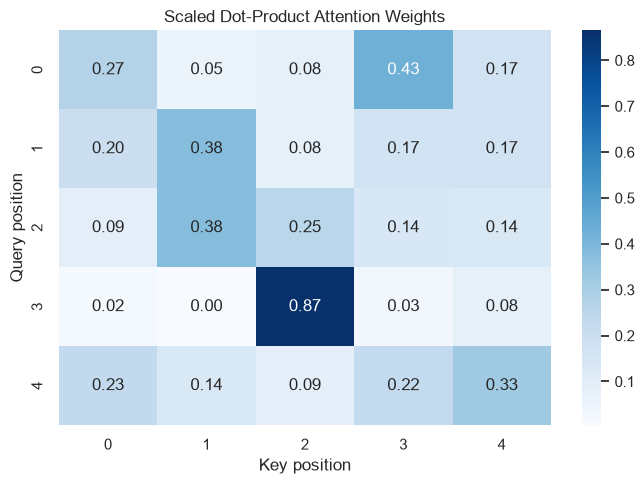

In [6]:
def softmax(x, axis=-1):
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(q, k, v):
    scores = q @ k.T / np.sqrt(q.shape[-1])
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return scores, weights, output


sequence_length = 5
dimension = 4
q = np.random.normal(size=(sequence_length, dimension))
k = np.random.normal(size=(sequence_length, dimension))
v = np.random.normal(size=(sequence_length, dimension))

attention_scores, attention_weights, attention_output = scaled_dot_product_attention(q, k, v)

print("Attention weight shape:", attention_weights.shape)
print("각 행의 합:", np.round(attention_weights.sum(axis=1), 6))
print("Attention output shape:", attention_output.shape)

plt.figure(figsize=(7, 5))
sns.heatmap(attention_weights, annot=True, fmt=".2f", cmap="Blues")
plt.title("Scaled Dot-Product Attention Weights")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.tight_layout()
plt.show()

### 6.2 Multi-Head Attention과 Positional Encoding

Multi-head attention은 attention을 여러 head로 나누어 서로 다른 관계를 동시에 학습합니다.

$$\operatorname{MultiHead}(Q,K,V)=\operatorname{Concat}(head_1,\ldots,head_h)W_O$$

Self-attention만으로는 입력 순서를 알 수 없으므로 위치 정보를 입력 표현에 더합니다.

$$PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

실제 모델에서는 고정된 사인·코사인 방식뿐 아니라 학습 가능한 위치 임베딩도 사용합니다.

Positional encoding shape: (50, 16)


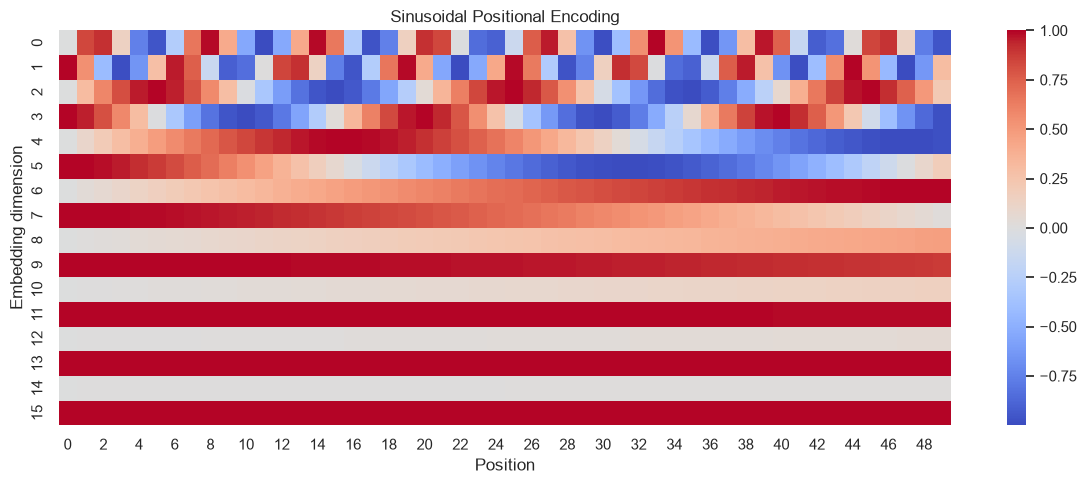

In [7]:
def positional_encoding(length, d_model):
    positions = np.arange(length)[:, None]
    dimensions = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / d_model)
    angles = positions * angle_rates
    encoding = np.zeros((length, d_model))
    encoding[:, 0::2] = np.sin(angles[:, 0::2])
    encoding[:, 1::2] = np.cos(angles[:, 1::2])
    return encoding


pe = positional_encoding(length=50, d_model=16)
print("Positional encoding shape:", pe.shape)

plt.figure(figsize=(12, 5))
sns.heatmap(pe.T, cmap="coolwarm", center=0)
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Position")
plt.ylabel("Embedding dimension")
plt.tight_layout()
plt.show()

### 6.3 Transformer Encoder와 장단점

일반적인 Encoder 블록은 다음과 같습니다.

```text
입력 + 위치 정보
→ Multi-Head Self-Attention
→ Residual Connection + Layer Normalization
→ Feed Forward Network
→ Residual Connection + Layer Normalization
```

장점:

- 멀리 떨어진 입력 요소 사이의 관계를 직접 학습할 수 있습니다.
- 순환 구조보다 병렬 처리가 쉽습니다.
- 텍스트, 이미지, 음성, 시계열과 센서 데이터에 적용할 수 있습니다.

한계:

- 기본 attention의 시간·메모리 복잡도는 토큰 수 $N$에 대해 $O(N^2)$입니다.
- CNN보다 지역성에 대한 사전 가정이 약해 더 많은 데이터가 필요할 수 있습니다.
- 작은 데이터셋에서는 과적합하거나 CNN보다 낮은 성능이 나올 수 있습니다.
- 위치 정보를 별도로 넣어야 합니다.

## 7. 다섯 구조 비교

각 구조는 서로 다른 문제를 해결하기 위해 등장했습니다. 어떤 구조가 항상 가장 좋다고 보기보다 데이터, 계산 자원과 해결하려는 문제에 따라 선택해야 합니다.

In [8]:
comparison = pd.DataFrame([
    ["Inception", "여러 크기의 연산을 병렬 적용", "다중 스케일 특징", "다양한 크기의 특징 동시 추출", "분기 설계가 복잡함"],
    ["ResNet", "shortcut으로 입력과 잔차를 더함", "깊은 모델의 최적화", "매우 깊은 모델 학습 가능", "깊이에 따른 연산량 증가"],
    ["SENet", "채널별 중요도를 학습하여 재가중", "유용한 채널 선택", "기존 CNN에 쉽게 결합", "공간 위치 중요도는 직접 반영하지 않음"],
    ["Depthwise Separable Conv", "공간 연산과 채널 결합 분리", "합성곱 계산량", "모바일·엣지 환경에 효율적", "표현력이 낮아질 수 있음"],
    ["Transformer", "Self-Attention으로 모든 토큰 관계 계산", "장거리 의존성", "전역 관계와 병렬 처리", "Attention 비용이 O(N²)"],
], columns=["구조", "핵심 아이디어", "해결하려는 문제", "장점", "한계"])

display(comparison)

,구조,핵심 아이디어,해결하려는 문제,장점,한계
0,Inception,여러 크기의 연산을 병렬 적용,다중 스케일 특징,다양한 크기의 특징 동시 추출,분기 설계가 복잡함
1,ResNet,shortcut으로 입력과 잔차를 더함,깊은 모델의 최적화,매우 깊은 모델 학습 가능,깊이에 따른 연산량 증가
2,SENet,채널별 중요도를 학습하여 재가중,유용한 채널 선택,기존 CNN에 쉽게 결합,공간 위치 중요도는 직접 반영하지 않음
3,Depthwise Separable Conv,공간 연산과 채널 결합 분리,합성곱 계산량,모바일·엣지 환경에 효율적,표현력이 낮아질 수 있음
4,Transformer,Self-Attention으로 모든 토큰 관계 계산,장거리 의존성,전역 관계와 병렬 처리,Attention 비용이 O(N²)


## 8. UCI HAR 센서 데이터와 연결해서 생각하기

UCI HAR의 입력은 `(128 시점, 9 센서 채널)`로 구성된 시계열입니다. 이미지용 2D 연산을 그대로 적용하기보다 Conv1D와 시계열 attention 형태로 바꾸어 생각해야 합니다.

- Inception: 서로 다른 크기의 Conv1D 커널을 병렬로 사용하여 짧은 움직임과 긴 주기를 함께 볼 수 있습니다.
- ResNet: Conv1D 블록에 shortcut을 추가하여 더 깊은 센서 모델을 안정적으로 학습할 수 있습니다.
- SENet: 9개 센서 채널 또는 CNN 특징 채널의 중요도를 학습할 수 있습니다.
- Depthwise Separable Conv: 가벼운 1D 모델을 만들어 모바일 센서 환경의 계산량을 줄일 수 있습니다.
- Transformer: 128개 시점 사이의 전역 관계를 학습할 수 있지만 UCI HAR처럼 데이터가 크지 않은 경우 과적합을 주의해야 합니다.

구조를 비교할 때는 동일한 피험자 단위 검증, seed, epoch와 평가 지표를 사용해야 합니다. 모델 이름만 바꾸고 평가 조건까지 달라지면 구조 자체의 효과를 판단하기 어렵습니다.

## 9. 전체 정리

이번에는 다섯 가지 딥러닝 구조가 어떤 문제를 해결하기 위해 만들어졌는지 확인했습니다.

- Inception은 여러 크기의 특징을 한 번에 추출합니다.
- ResNet은 잔차 연결로 깊은 모델의 학습을 쉽게 합니다.
- SENet은 중요한 특징 채널을 학습하여 강조합니다.
- Depthwise separable convolution은 공간 연산과 채널 결합을 나누어 계산량을 줄입니다.
- Transformer는 self-attention을 통해 입력 전체의 관계를 학습합니다.

핵심은 어떤 구조가 무조건 가장 좋다는 것이 아니라, 현재 모델의 문제가 다중 스케일, 깊이, 채널 선택, 계산 효율, 장거리 관계 중 어디에 있는지 먼저 판단하는 것입니다.

## 10. 참고 논문

- Szegedy et al., *Going Deeper with Convolutions* (GoogLeNet/Inception), 2014
- He et al., *Deep Residual Learning for Image Recognition* (ResNet), 2015
- Hu et al., *Squeeze-and-Excitation Networks* (SENet), 2017
- Howard et al., *MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications*, 2017
- Vaswani et al., *Attention Is All You Need* (Transformer), 2017